# Linear versus nonlinear contrastive encoders

We compare linear encoders against MLP nonlinear encoders on pure-noise data, linear paired-signal data, and cubic paired-signal data. The goal is to see when nonlinear capacity helps learn a relationship between two random views, and when it mainly increases the risk of fitting noise.


## 1. Imports

The path setup lets this notebook work whether Jupyter starts in `contrastive-residual-encoder/` or in the larger notes folder.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import pandas as pd
import torch

GLOBAL_SEED = 123
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

P_DIM = 128
Q_DIM = 128

cwd = Path.cwd()
if (cwd / "contrastive_encoders").exists():
    module_root = cwd
else:
    raise RuntimeError("Could not find the contrastive_encoders package folder.")

if str(module_root) not in sys.path:
    sys.path.insert(0, str(module_root))

PLOT_DIR = module_root / "report-plots"
PLOT_DIR.mkdir(exist_ok=True)

print("DEVICE:", DEVICE)
print("module_root:", module_root)
print("plot output:", PLOT_DIR)


DEVICE: cpu
module_root: /Users/b4her/Downloads/UTSSRP - notes/experiments/contrastive-residual-encoder
plot output: /Users/b4her/Downloads/UTSSRP - notes/experiments/contrastive-residual-encoder/report-plots


In [2]:
import importlib

import contrastive_encoders
from contrastive_encoders import (
    architectures,
    data,
    experiments,
    losses,
    metrics,
    plotting,
    regularization,
    training,
)

for module in [
    architectures,
    data,
    losses,
    metrics,
    regularization,
    training,
    experiments,
    plotting,
]:
    importlib.reload(module)

importlib.reload(contrastive_encoders)

from contrastive_encoders import (
    TrainConfig,
    friendly_results_table,
    make_experiment_datasets,
    make_first_experiment_configs,
    make_model_spec_table,
    paper_contrastive_loss,
    plot_alpha_sweep_curve,
    plot_branch_ratio_history,
    plot_deterministic_snr_sweep,
    plot_latent_probe_r2_by_config,
    plot_metric_by_config,
    plot_signal_noise_sweep,
    plot_signal_recovery_by_config,
    plot_similarity_heatmap,
    plot_top5_retrieval_by_setting,
    plot_train_test_separation_by_setting,
    run_alpha_sweep,
    run_deterministic_relation_experiment,
    run_first_experiment,
    run_signal_noise_sweep,
    train_one_model_with_artifacts,
)


## 2. Mathematical objective

For embeddings `z_x = f_X(X)` and `z_y = f_Y(Y)`, define

```text
s_ij = <z_x_i, z_y_j>
```

The paper objective maximizes

```text
L = sum_i s_ii
    - sum_i log sum_j exp(s_ij)
    - sum_i log sum_j exp(s_ji)
```

The training code minimizes `-L / N` using `paper_contrastive_loss(...)`.

Important: this is **not** the standard cross-entropy InfoNCE replacement. By default it uses raw inner products, no loss-side normalization, and temperature `1.0`. The encoder architecture now has internal branch normalization so `alpha` controls the nonlinear correction, but the paper loss itself is unchanged.


## 3. Model comparison grid

The pure linear baseline is now a normalized linear encoder:

```text
g(u) = Normalize(G u)
```

The residual nonlinear models normalize both branches so `alpha` controls the nonlinear correction:

```text
g(u) = Normalize(G u) + alpha * Normalize(A1 sigma(A2 u + b))
```

The normalization layers use `BatchNorm1d(..., affine=False)`. The `affine=False` part is important because it prevents a learned scale parameter from secretly undoing `alpha`.

This also keeps the pure linear embedding scale controlled before the raw-dot-product loss sees it. So `alpha=0` means no nonlinear correction, while larger `alpha` lets the normalized MLP correction contribute more strongly.


In [3]:
configs = make_first_experiment_configs(epochs=300)
model_table = make_model_spec_table(configs, p=P_DIM, q=Q_DIM)
display(model_table)


,Model,Plain meaning,Encoder formula,Linear layer sizes,Nonlinear layer sizes,Embedding dim,Hidden dim,Alpha,Alpha meaning,Normalization,Nonlinear role,L1 penalty,L2 penalty,Trainable parameters
0,Linear encoder (alpha=0),Only a normalized linear map for X and Y,g(u) = Normalize(G u),X G: 128->4; Y G: 128->4,none,4,none,0.00,alpha is not used for the pure linear baseline,encoder output uses BatchNorm1d affine=False,"alpha=0, so no nonlinear correction is added",none,none,1024
1,MLP nonlinear (alpha=0.01),Linear map plus a one-hidden-layer MLP correction,g(u) = Normalize(G u) + alpha * Normalize(A1 s...,X G: 128->4; Y G: 128->4,"X A2: 128->16, X A1: 16->4; Y A2: 128->16, Y A...",4,16,0.01,alpha multiplies the normalized nonlinear corr...,residual branches use BatchNorm1d affine=False,alpha=0.01 scales the normalized MLP correction,none,none,5280
2,MLP nonlinear (alpha=0.10),Linear map plus a one-hidden-layer MLP correction,g(u) = Normalize(G u) + alpha * Normalize(A1 s...,X G: 128->4; Y G: 128->4,"X A2: 128->16, X A1: 16->4; Y A2: 128->16, Y A...",4,16,0.10,alpha multiplies the normalized nonlinear corr...,residual branches use BatchNorm1d affine=False,alpha=0.1 scales the normalized MLP correction,none,none,5280
3,MLP nonlinear (alpha=1.00),Linear map plus a one-hidden-layer MLP correction,g(u) = Normalize(G u) + alpha * Normalize(A1 s...,X G: 128->4; Y G: 128->4,"X A2: 128->16, X A1: 16->4; Y A2: 128->16, Y A...",4,16,1.00,alpha multiplies the normalized nonlinear corr...,residual branches use BatchNorm1d affine=False,alpha=1 scales the normalized MLP correction,none,none,5280
4,L1-regularized nonlinear (alpha=0.10),Linear map plus a one-hidden-layer MLP correction,g(u) = Normalize(G u) + alpha * Normalize(A1 s...,X G: 128->4; Y G: 128->4,"X A2: 128->16, X A1: 16->4; Y A2: 128->16, Y A...",4,16,0.10,alpha multiplies the normalized nonlinear corr...,residual branches use BatchNorm1d affine=False,alpha=0.1 scales the normalized MLP correction,A2=0.0001,none,5280
5,L2-regularized nonlinear (alpha=0.10),Linear map plus a one-hidden-layer MLP correction,g(u) = Normalize(G u) + alpha * Normalize(A1 s...,X G: 128->4; Y G: 128->4,"X A2: 128->16, X A1: 16->4; Y A2: 128->16, Y A...",4,16,0.10,alpha multiplies the normalized nonlinear corr...,residual branches use BatchNorm1d affine=False,alpha=0.1 scales the normalized MLP correction,none,A1/A2=0.0001,5280


## 4. Run pure-noise, linear-signal, and cubic-signal experiments

The experiment creates three datasets:

- `Noise only`: X and Y are independent noise, so there is no real paired signal.
- `Linear signal`: X has latent `Z_x`, Y has latent `Z_y`, and the relationship is `Z_y = Z_x`.
- `Cubic signal`: X has latent `Z_x`, Y has latent `Z_y`, and the relationship is `Z_y = standardized(Z_x ** 3)`.

This is closer to the caption/image analogy: the two views are different random datasets, but their hidden variables are related when a signal is present. Every model uses the same paper contrastive loss, so differences should come from model capacity and regularization.


In [4]:
results = run_first_experiment(
    configs=configs,
    seed=GLOBAL_SEED,
    device=DEVICE,
    n_train=160,
    n_test=800,
    p=P_DIM,
    q=Q_DIM,
    signal_strength=2.0,
    noise_std=1.0,
)

results


,setting,config,architecture,embedding_dim,hidden_dim,nonlinear_scale,normalize_linear_part,l1_linear,l1_nonlinear,l2_linear,...,x_probe_r2_z_x,x_probe_r2_z_y,y_probe_r2_z_y,x_linear_branch_norm,x_nonlinear_branch_norm,x_nonlinear_to_linear_ratio,y_linear_branch_norm,y_nonlinear_branch_norm,y_nonlinear_to_linear_ratio,mean_nonlinear_to_linear_ratio
0,Noise only,Linear encoder (alpha=0),linear,4,0,0.00,True,0.0,0.0000,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Linear signal,Linear encoder (alpha=0),linear,4,0,0.00,True,0.0,0.0000,0.0,...,0.149317,0.149317,0.153143,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Cubic signal,Linear encoder (alpha=0),linear,4,0,0.00,True,0.0,0.0000,0.0,...,0.094494,0.049064,0.155226,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Noise only,MLP nonlinear (alpha=0.01),residual,4,16,0.01,True,0.0,0.0000,0.0,...,NaN,NaN,NaN,1.866164,0.018704,0.010023,1.781436,0.019416,0.010899,0.010461
4,Linear signal,MLP nonlinear (alpha=0.01),residual,4,16,0.01,True,0.0,0.0000,0.0,...,0.033547,0.033547,0.220868,1.895128,0.021211,0.011193,1.822931,0.019283,0.010578,0.010885
5,Cubic signal,MLP nonlinear (alpha=0.01),residual,4,16,0.01,True,0.0,0.0000,0.0,...,0.130910,0.101099,0.080782,1.844159,0.019802,0.010738,1.945187,0.019941,0.010251,0.010495
6,Noise only,MLP nonlinear (alpha=0.10),residual,4,16,0.10,True,0.0,0.0000,0.0,...,NaN,NaN,NaN,1.739613,0.196741,0.113095,1.769547,0.212591,0.120138,0.116617
7,Linear signal,MLP nonlinear (alpha=0.10),residual,4,16,0.10,True,0.0,0.0000,0.0,...,0.407462,0.407462,-0.106702,1.769418,0.220562,0.124652,1.701594,0.203286,0.119468,0.122060
8,Cubic signal,MLP nonlinear (alpha=0.10),residual,4,16,0.10,True,0.0,0.0000,0.0,...,0.230277,0.110724,0.214140,1.773773,0.198220,0.111750,1.877576,0.215258,0.114647,0.113199
9,Noise only,MLP nonlinear (alpha=1.00),residual,4,16,1.00,True,0.0,0.0000,0.0,...,NaN,NaN,NaN,1.743976,1.595543,0.914888,1.809877,1.764657,0.975015,0.944951


## 5. Focused comparison table

These are the main metrics in friendlier language:

- **True-pair separation**: true X/Y pairs score higher than mismatched pairs. Higher is better.
- **Shuffled-pair check**: the same score after breaking the X/Y pairing. This should stay near zero.
- **Exact-pair accuracy**: how often the closest Y is the true paired Y. Higher is better.
- **Top-5 retrieval accuracy**: how often the true paired Y is among the 5 closest Y candidates. Higher is better.
- **X embedding vs Z_x**: correlation between the X embedding and the true X latent.
- **X embedding vs Z_y**: correlation between the X embedding and the paired Y latent. In the cubic setting, this means `Z_y = standardized(Z_x ** 3)`.
- **Y embedding vs Z_y**: correlation between the Y embedding and the true Y latent.
- **Ridge-probe R^2**: percent of held-out latent variation explained by a simple ridge regression from the learned embedding.
- **Mean nonlinear/linear ratio**: diagnostic check that the measured nonlinear branch size follows `alpha`.


In [5]:
summary_columns = [
    "setting",
    "config",
    "architecture",
    "parameter_count",
    "parameter_count_per_train_sample",
    "train_pair_separation",
    "test_pair_separation",
    "shuffled_pair_separation",
    "test_pair_match_accuracy",
    "test_top5_pair_match_accuracy",
    "test_best_view_correlation",
    "x_signal_recovery",
    "x_related_signal_recovery",
    "y_signal_recovery",
    "x_probe_r2_z_x",
    "x_probe_r2_z_y",
    "y_probe_r2_z_y",
    "mean_nonlinear_to_linear_ratio",
]

summary_table = friendly_results_table(results[summary_columns].round(4))
display(summary_table)


,Dataset,Model,Architecture,Trainable parameters,Parameters per training pair,Train true-pair separation,Test true-pair separation,Shuffled-pair check,Test exact-pair accuracy,Test top-5 retrieval accuracy,Test X/Y embedding correlation,X signal recovery,X recovery of paired Y latent,Y signal recovery,X probe R^2 for Z_x,X probe R^2 for Z_y,Y probe R^2 for Z_y,Mean nonlinear/linear ratio
0,Noise only,Linear encoder (alpha=0),linear,1024,6.4,0.6401,-0.0011,-0.0215,0.0000,0.0088,0.0418,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Linear signal,Linear encoder (alpha=0),linear,1024,6.4,0.6764,0.0454,0.0199,0.0012,0.0075,0.0744,0.2483,0.2483,0.3047,0.1493,0.1493,0.1531,NaN
2,Cubic signal,Linear encoder (alpha=0),linear,1024,6.4,0.6732,0.0246,0.0278,0.0012,0.0038,0.1661,0.3045,0.2579,0.4850,0.0945,0.0491,0.1552,NaN
3,Noise only,MLP nonlinear (alpha=0.01),residual,5280,33.0,0.6488,0.0011,-0.0023,0.0012,0.0088,0.0381,NaN,NaN,NaN,NaN,NaN,NaN,0.0105
4,Linear signal,MLP nonlinear (alpha=0.01),residual,5280,33.0,0.6462,0.0760,0.0147,0.0000,0.0050,0.1062,0.3279,0.3279,0.4735,0.0335,0.0335,0.2209,0.0109
5,Cubic signal,MLP nonlinear (alpha=0.01),residual,5280,33.0,0.6582,0.0407,0.0174,0.0038,0.0062,0.1284,0.2919,0.2532,0.4946,0.1309,0.1011,0.0808,0.0105
6,Noise only,MLP nonlinear (alpha=0.10),residual,5280,33.0,0.6712,0.0155,-0.0032,0.0012,0.0050,0.0415,NaN,NaN,NaN,NaN,NaN,NaN,0.1166
7,Linear signal,MLP nonlinear (alpha=0.10),residual,5280,33.0,0.6836,0.0578,0.0076,0.0025,0.0062,0.1150,0.5970,0.5970,0.2692,0.4075,0.4075,-0.1067,0.1221
8,Cubic signal,MLP nonlinear (alpha=0.10),residual,5280,33.0,0.7013,0.0282,0.0020,0.0012,0.0100,0.1331,0.4851,0.3637,0.3760,0.2303,0.1107,0.2141,0.1132
9,Noise only,MLP nonlinear (alpha=1.00),residual,5280,33.0,0.9417,0.0013,-0.0136,0.0012,0.0038,0.0637,NaN,NaN,NaN,NaN,NaN,NaN,0.9450


## 6. Main plots

These plots separate the questions:

- Does the model memorize training pairs without generalizing?
- Does true-pair separation survive on held-out pairs?
- Is the true paired Y inside the top 5 retrieved candidates?
- Does the embedding recover `Z_x`, the transformed paired latent `Z_y`, or both?
- How much held-out latent variation is explained by a ridge probe from the embedding?
- Does the measured branch contribution follow `alpha`?

Each plot is also saved as a PNG in `report-plots/` with a readable file name.


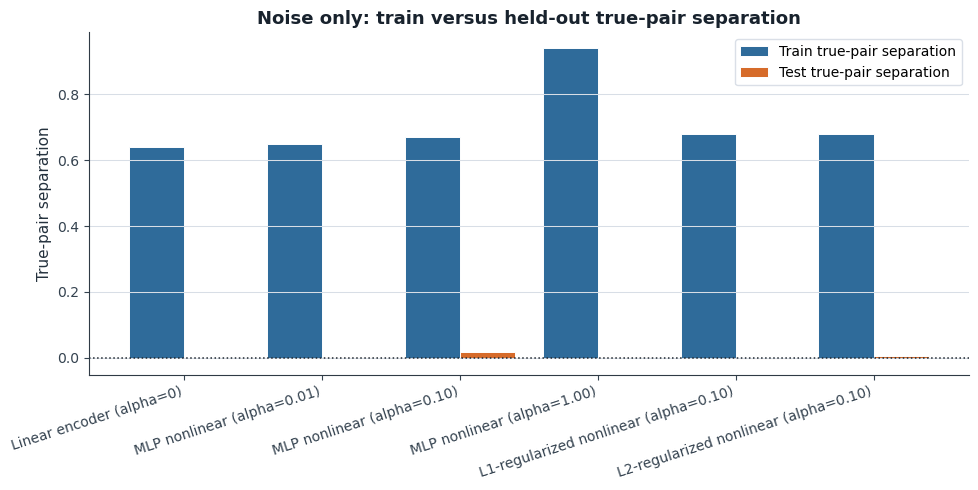

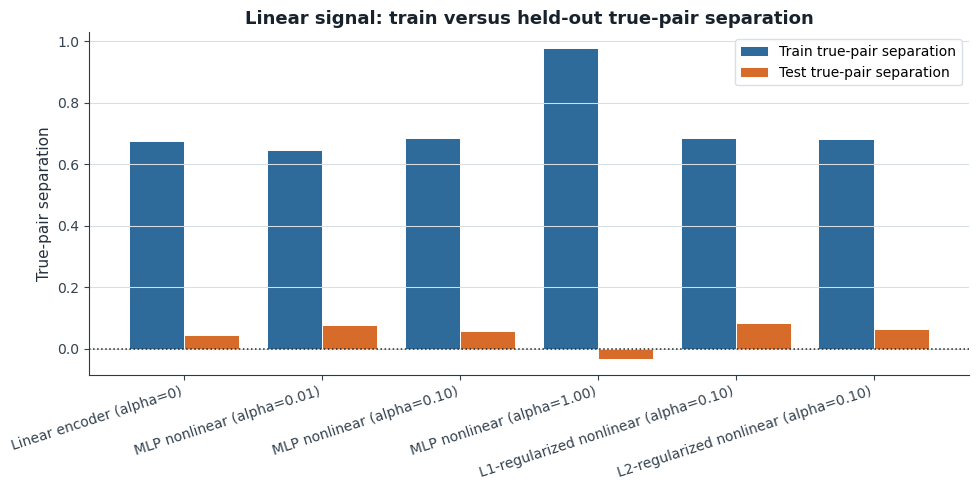

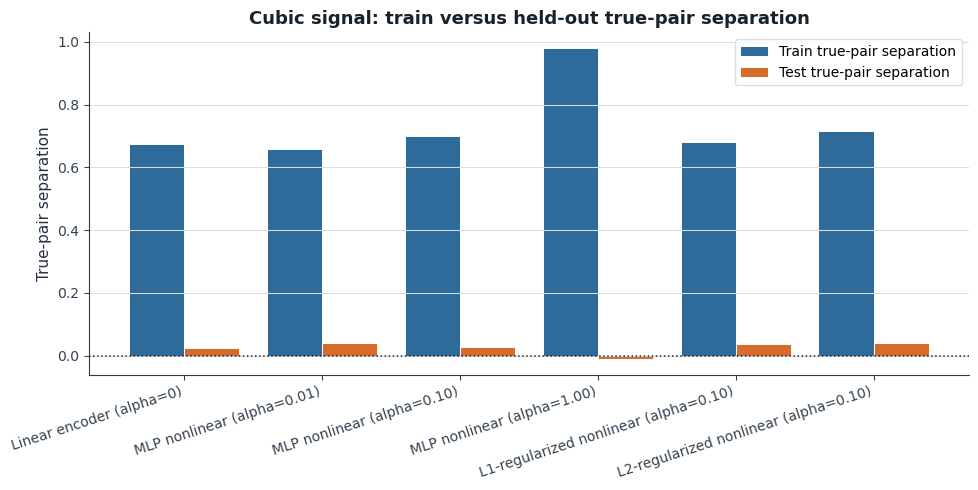

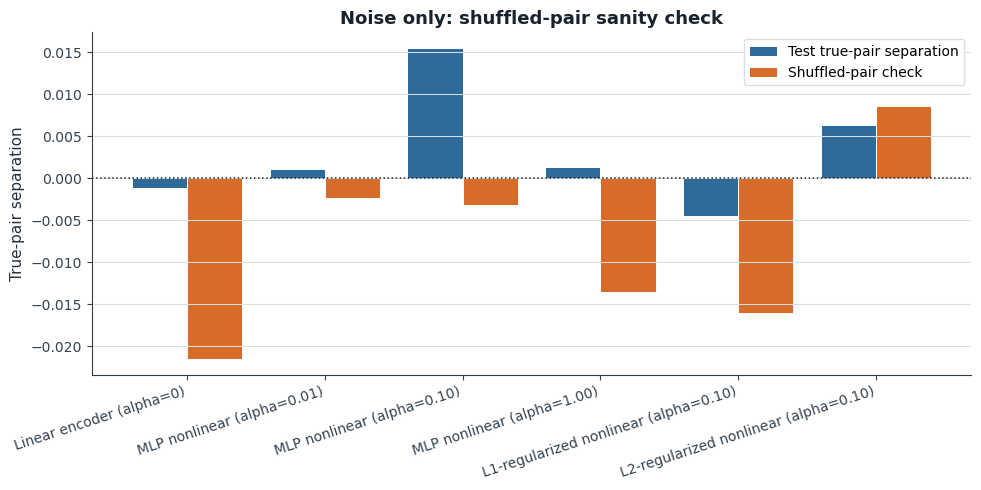

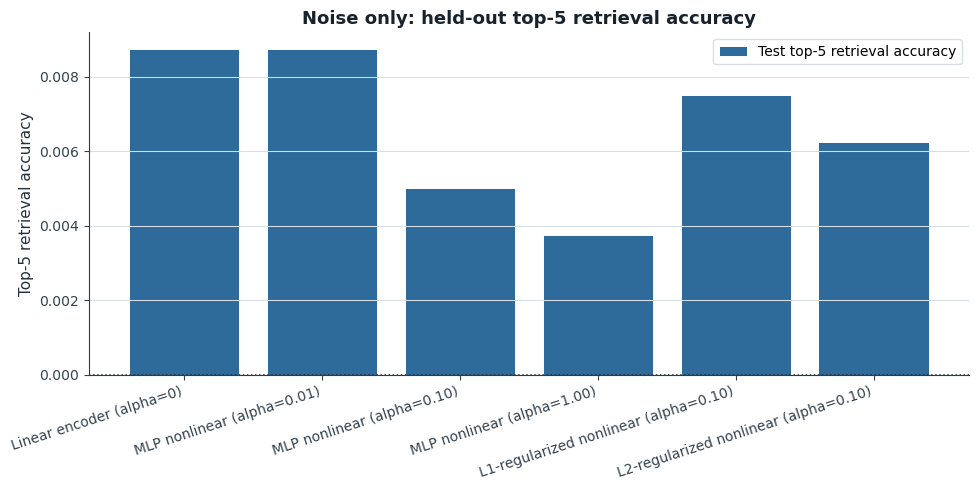

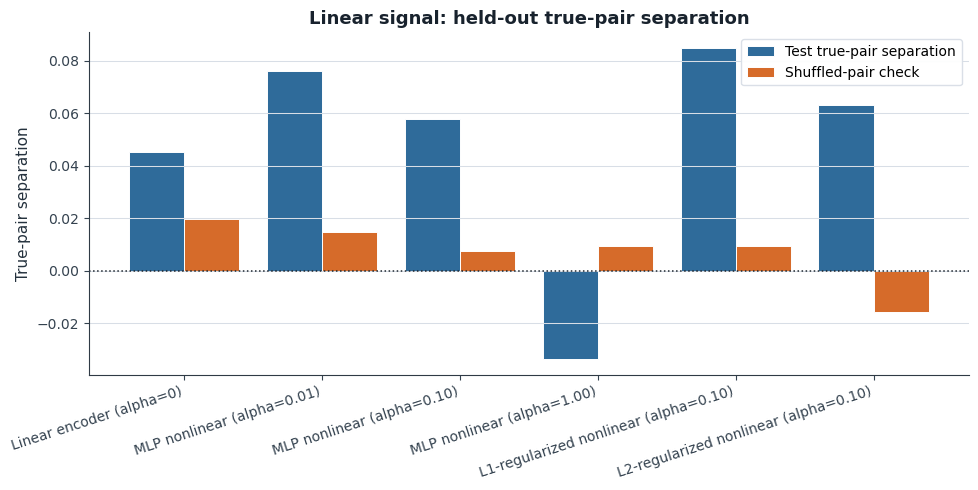

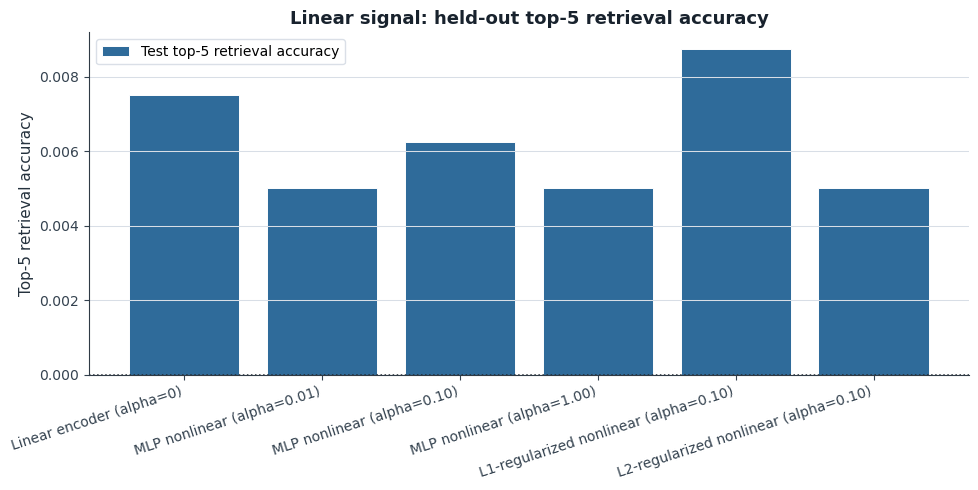

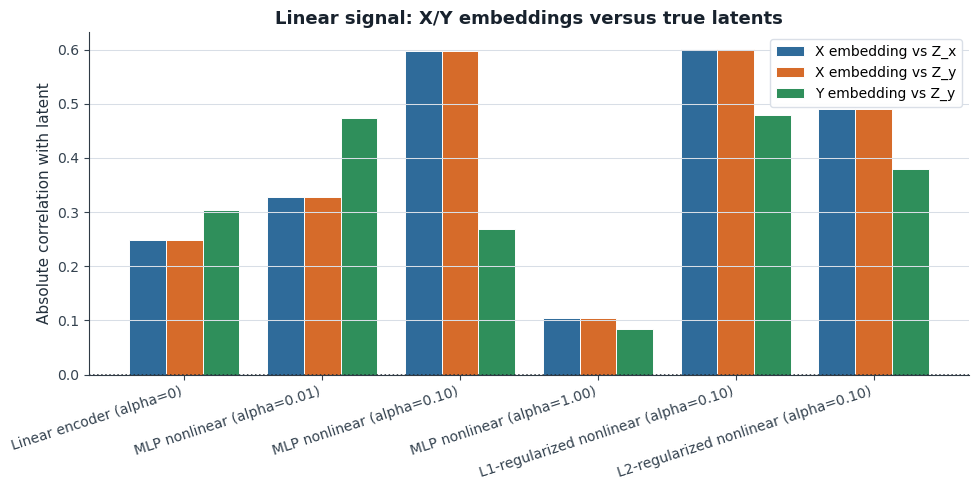

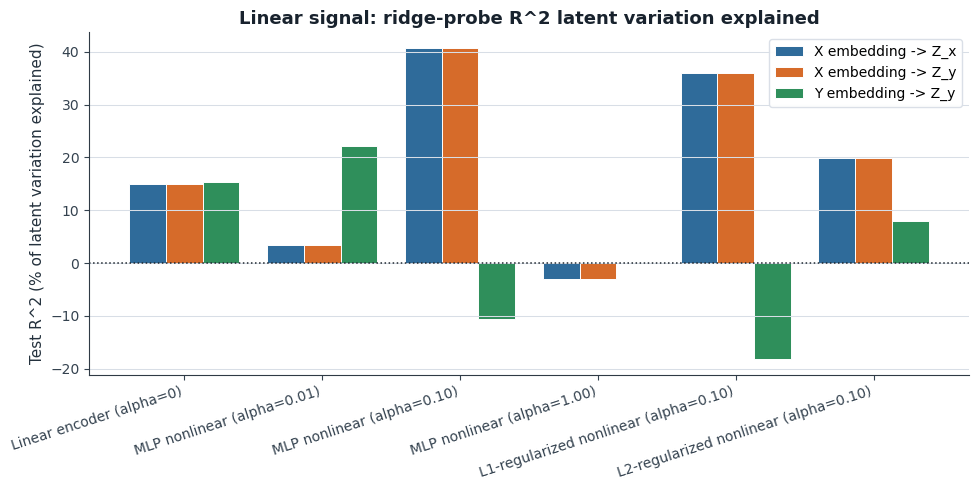

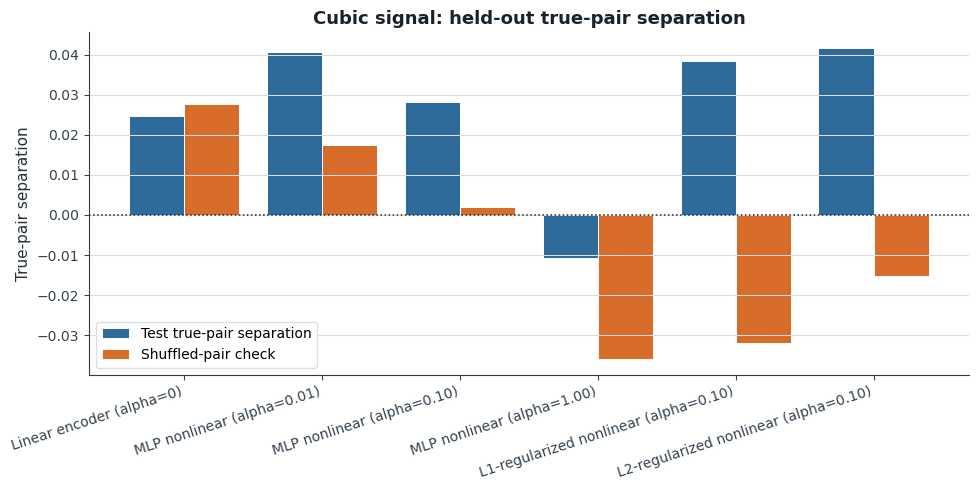

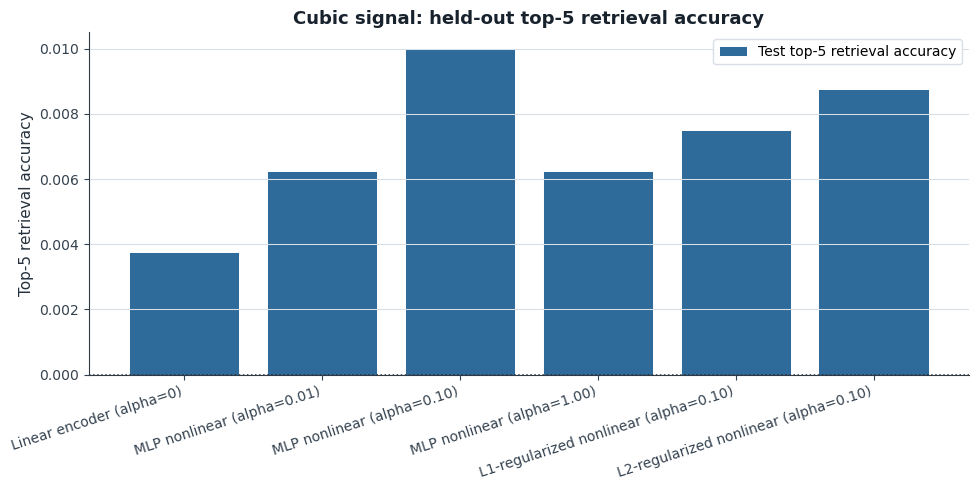

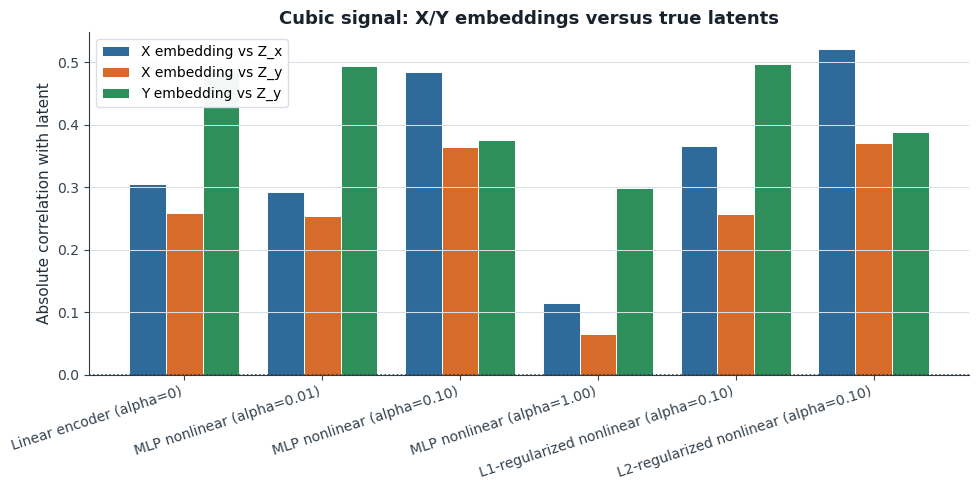

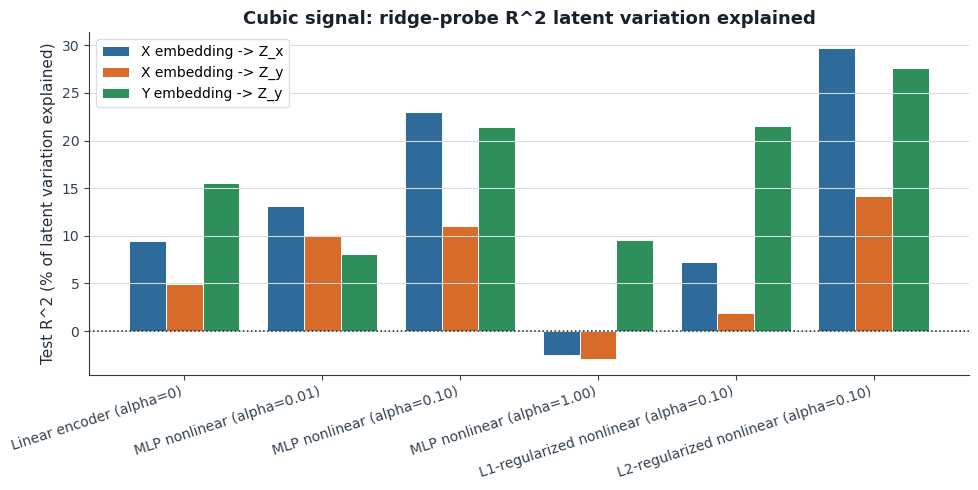

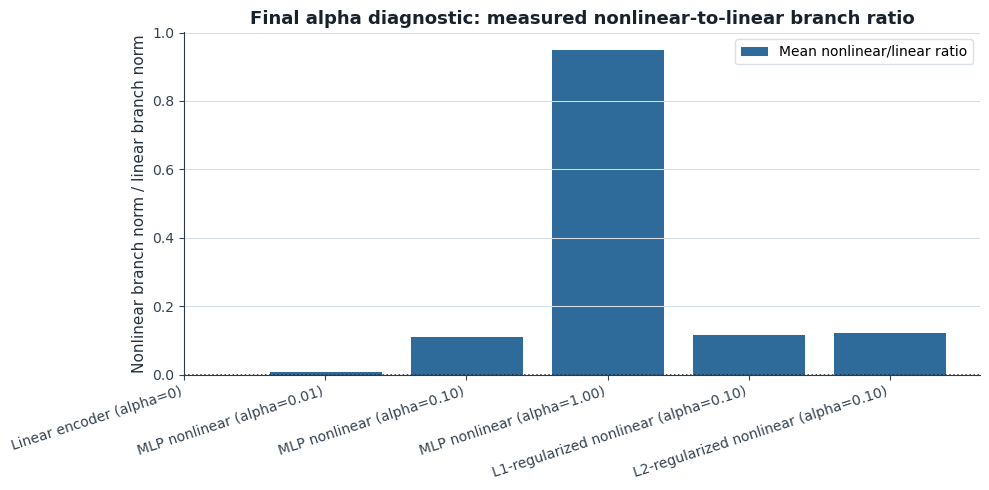

PosixPath('/Users/b4her/Downloads/UTSSRP - notes/experiments/contrastive-residual-encoder/report-plots/final-alpha-diagnostic-measured-nonlinear-to-linear-branch-ratio.png')

In [6]:
for setting_name in ["Noise only", "Linear signal", "Cubic signal"]:
    plot_train_test_separation_by_setting(
        results,
        setting=setting_name,
        save_dir=PLOT_DIR,
    )

plot_metric_by_config(
    results,
    setting="Noise only",
    metrics=[
        "test_pair_separation",
        "shuffled_pair_separation",
    ],
    title="Noise only: shuffled-pair sanity check",
    ylabel="True-pair separation",
    save_dir=PLOT_DIR,
)
plot_top5_retrieval_by_setting(
    results,
    setting="Noise only",
    save_dir=PLOT_DIR,
)

for setting_name in ["Linear signal", "Cubic signal"]:
    plot_metric_by_config(
        results,
        setting=setting_name,
        metrics=[
            "test_pair_separation",
            "shuffled_pair_separation",
        ],
        title=f"{setting_name}: held-out true-pair separation",
        ylabel="True-pair separation",
        save_dir=PLOT_DIR,
    )

    plot_top5_retrieval_by_setting(
        results,
        setting=setting_name,
        save_dir=PLOT_DIR,
    )

    plot_signal_recovery_by_config(
        results,
        setting=setting_name,
        title=f"{setting_name}: X/Y embeddings versus true latents",
        save_dir=PLOT_DIR,
    )

    plot_latent_probe_r2_by_config(
        results,
        setting=setting_name,
        title=f"{setting_name}: ridge-probe R^2 latent variation explained",
        save_dir=PLOT_DIR,
    )

plot_metric_by_config(
    results,
    setting="Cubic signal",
    metrics=[
        "mean_nonlinear_to_linear_ratio",
    ],
    title="Final alpha diagnostic: measured nonlinear-to-linear branch ratio",
    ylabel="Nonlinear branch norm / linear branch norm",
    save_dir=PLOT_DIR,
)


## 7. Branch history and similarity heatmaps

This section retrains the residual models on both the linear-signal and cubic-signal datasets so we can inspect training dynamics, not just final metrics.

The branch-history plot tracks:

```text
|| nonlinear branch || / || linear branch ||
```

over epochs. The heatmap plots `S = z_x z_y^T` for a small held-out batch. A clear bright diagonal means the model gives true X/Y pairs higher similarity than mismatched pairs. These figures are saved to `report-plots/`.


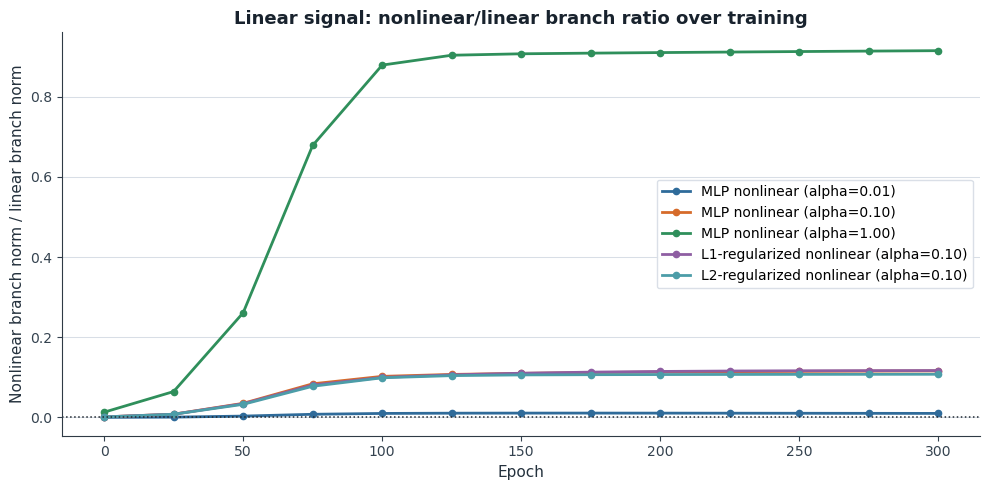

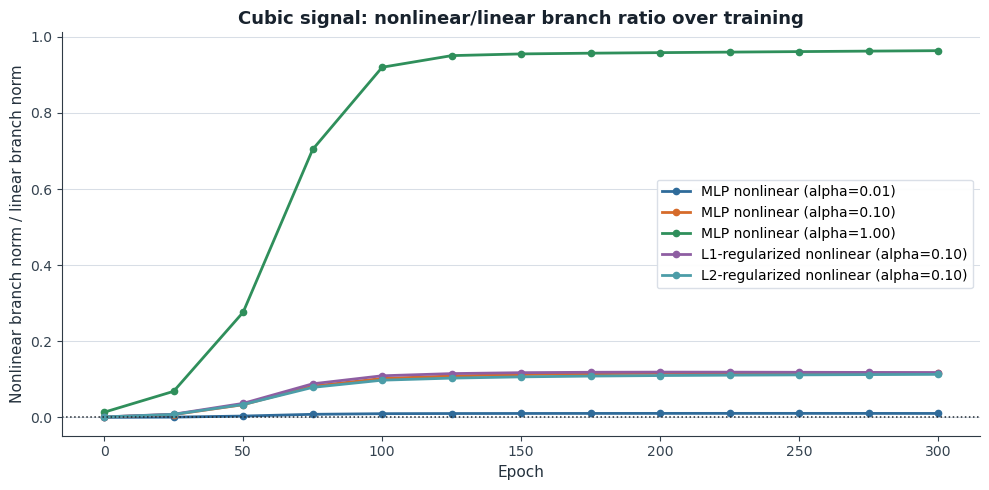

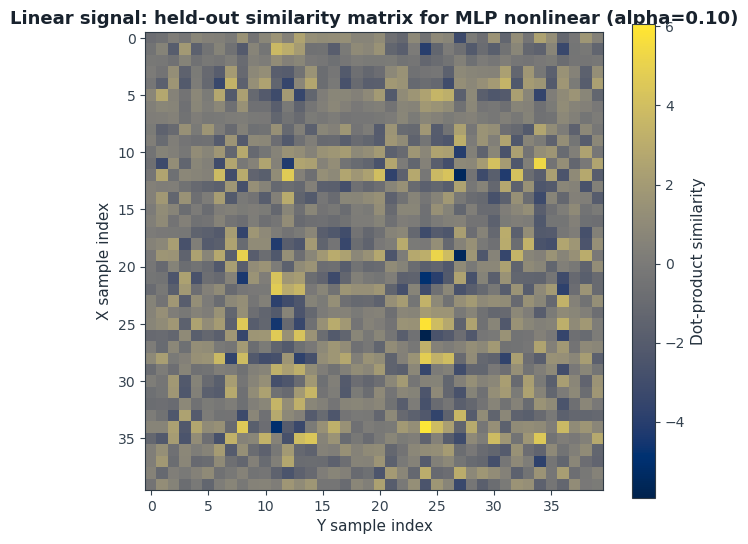

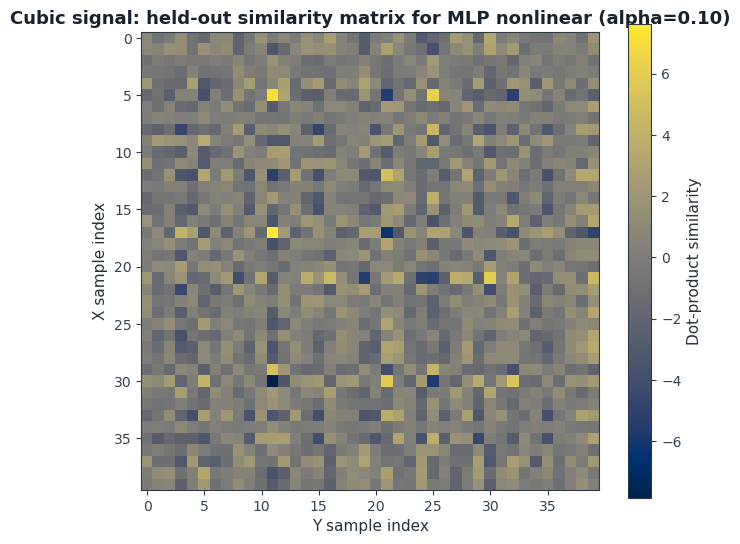

In [7]:
diagnostic_datasets = make_experiment_datasets(
    seed=GLOBAL_SEED,
    n_train=160,
    n_test=800,
    p=P_DIM,
    q=Q_DIM,
    signal_strength=2.0,
    noise_std=1.0,
)

diagnostic_configs = [
    config for config in configs
    if config.architecture == "residual"
]

diagnostic_settings = ["Linear signal", "Cubic signal"]
diagnostic_runs = {}
all_history_frames = []

for setting_index, setting_name in enumerate(diagnostic_settings):
    diagnostic_runs[setting_name] = {}
    setting_history_frames = []

    for config_index, config in enumerate(diagnostic_configs):
        run = train_one_model_with_artifacts(
            dataset=diagnostic_datasets[setting_name],
            config=config,
            seed=GLOBAL_SEED + 200 + 100 * setting_index + config_index,
            device=DEVICE,
            standardize=True,
            history_interval=25,
        )
        diagnostic_runs[setting_name][config.name] = run

        history = pd.DataFrame(run.history)
        history["setting"] = setting_name
        history["config"] = config.name
        setting_history_frames.append(history)
        all_history_frames.append(history)

    setting_branch_history = pd.concat(setting_history_frames, ignore_index=True)
    plot_branch_ratio_history(
        setting_branch_history,
        title=f"{setting_name}: nonlinear/linear branch ratio over training",
        save_dir=PLOT_DIR,
    )

selected_heatmap_model = "MLP nonlinear (alpha=0.10)"

for setting_name in diagnostic_settings:
    heatmap_run = diagnostic_runs[setting_name][selected_heatmap_model]
    plot_similarity_heatmap(
        heatmap_run.z_x_test,
        heatmap_run.z_y_test,
        n=40,
        title=f"{setting_name}: held-out similarity matrix for {selected_heatmap_model}",
        save_dir=PLOT_DIR,
    )

branch_history = pd.concat(all_history_frames, ignore_index=True)


## 8. Alpha sweep

This tests a denser alpha grid:

```text
alpha = [0.0, 0.01, 0.03, 0.1, 0.3, 1.0]
```

The plot asks whether there is a useful middle range where the nonlinear correction is strong enough to help but not so strong that it overfits or destabilizes. The figure is saved to `report-plots/`.


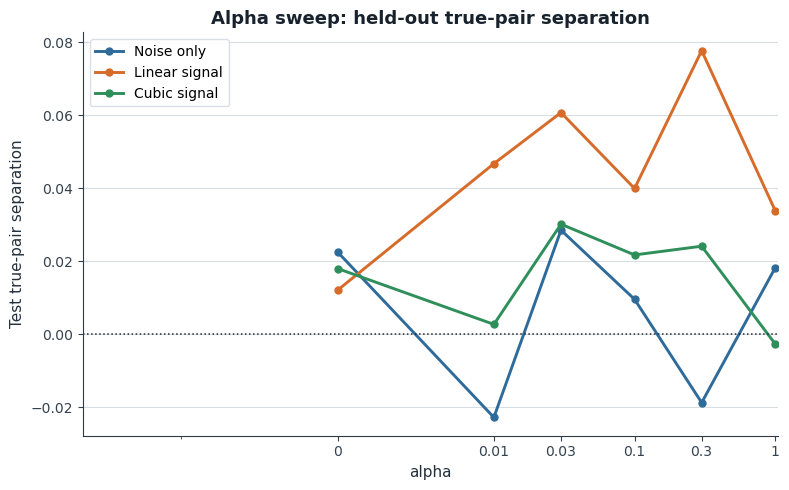

,Dataset,Model,Alpha,Test true-pair separation,Shuffled-pair check,Test top-5 retrieval accuracy,X signal recovery,X recovery of paired Y latent,Y signal recovery,X probe R^2 for Z_x,X probe R^2 for Z_y,Y probe R^2 for Z_y,Mean nonlinear/linear ratio
0,Noise only,MLP nonlinear (alpha=0.00),0.00,0.0226,-0.0343,0.0075,NaN,NaN,NaN,NaN,NaN,NaN,0.0000
1,Linear signal,MLP nonlinear (alpha=0.00),0.00,0.0121,-0.0236,0.0038,0.4197,0.4197,0.2307,0.0708,0.0708,-0.2893,0.0000
2,Cubic signal,MLP nonlinear (alpha=0.00),0.00,0.0180,-0.0177,0.0050,0.2463,0.1881,0.3107,-0.1070,-0.1015,0.0124,0.0000
3,Noise only,MLP nonlinear (alpha=0.01),0.01,-0.0227,0.0065,0.0025,NaN,NaN,NaN,NaN,NaN,NaN,0.0091
4,Linear signal,MLP nonlinear (alpha=0.01),0.01,0.0468,0.0094,0.0075,0.4869,0.4869,0.2989,0.2958,0.2958,-0.1259,0.0107
5,Cubic signal,MLP nonlinear (alpha=0.01),0.01,0.0027,0.0078,0.0062,0.4099,0.3532,0.2653,0.1413,0.0420,0.0860,0.0109
6,Noise only,MLP nonlinear (alpha=0.03),0.03,0.0286,-0.0106,0.0112,NaN,NaN,NaN,NaN,NaN,NaN,0.0317
7,Linear signal,MLP nonlinear (alpha=0.03),0.03,0.0608,-0.0318,0.0050,0.3049,0.3049,0.5001,-0.1451,-0.1451,0.1474,0.0354
8,Cubic signal,MLP nonlinear (alpha=0.03),0.03,0.0302,0.0302,0.0088,0.3903,0.3444,0.2154,0.1069,0.0216,-0.0069,0.0345
9,Noise only,MLP nonlinear (alpha=0.10),0.10,0.0096,-0.0034,0.0050,NaN,NaN,NaN,NaN,NaN,NaN,0.1210


In [8]:
alpha_sweep_results = run_alpha_sweep(
    seed=GLOBAL_SEED + 500,
    device=DEVICE,
    alphas=[0.0, 0.01, 0.03, 0.1, 0.3, 1.0],
    epochs=300,
    n_train=160,
    n_test=800,
    p=P_DIM,
    q=Q_DIM,
    signal_strength=2.0,
    noise_std=1.0,
)

plot_alpha_sweep_curve(
    alpha_sweep_results,
    metric="test_pair_separation",
    title="Alpha sweep: held-out true-pair separation",
    save_dir=PLOT_DIR,
)

display(
    friendly_results_table(
        alpha_sweep_results[
            [
                "setting",
                "config",
                "nonlinear_scale",
                "test_pair_separation",
                "shuffled_pair_separation",
                "test_top5_pair_match_accuracy",
                "x_signal_recovery",
                "x_related_signal_recovery",
                "y_signal_recovery",
                "x_probe_r2_z_x",
                "x_probe_r2_z_y",
                "y_probe_r2_z_y",
                "mean_nonlinear_to_linear_ratio",
            ]
        ].round(4)
    )
)


## 9. Signal strength / noise sweep

This sweep varies:

```text
signal_strength_values = [1.0, 2.0, 3.0, 5.0]
noise_std_values = [0.25, 0.5, 1.0, 2.0]
```

The x-axis is `signal_strength / noise_std`. If all models fail at low ratios and improve at high ratios, then the issue may be weak signal rather than the encoder architecture. The figure is saved to `report-plots/`.


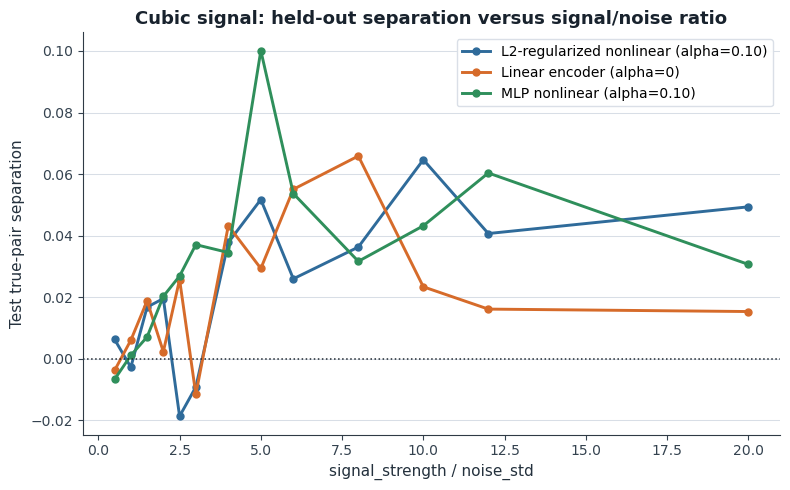

,Dataset,Model,signal_strength,noise_std,signal_to_noise,Test true-pair separation,Shuffled-pair check,Test top-5 retrieval accuracy,X signal recovery,X recovery of paired Y latent,Y signal recovery,X probe R^2 for Z_x,X probe R^2 for Z_y,Y probe R^2 for Z_y
0,Cubic signal,Linear encoder (alpha=0),1.0,0.25,4.0,0.0654,-0.0001,0.0150,0.6997,0.5710,0.6151,0.3426,0.1815,0.2584
1,Cubic signal,MLP nonlinear (alpha=0.10),1.0,0.25,4.0,0.0480,0.0075,0.0100,0.7795,0.6331,0.2056,0.7309,0.4463,0.1397
2,Cubic signal,L2-regularized nonlinear (alpha=0.10),1.0,0.25,4.0,0.0584,-0.0089,0.0225,0.8389,0.6777,0.3640,0.8010,0.4688,0.3334
3,Cubic signal,Linear encoder (alpha=0),1.0,0.50,2.0,0.0096,0.0142,0.0050,0.4420,0.3861,0.1973,0.1769,0.1019,-0.2187
4,Cubic signal,MLP nonlinear (alpha=0.10),1.0,0.50,2.0,0.0193,-0.0075,0.0112,0.3644,0.3144,0.4041,-0.0109,-0.1097,0.1428
5,Cubic signal,L2-regularized nonlinear (alpha=0.10),1.0,0.50,2.0,0.0271,0.0013,0.0075,0.3592,0.3011,0.2150,0.0407,-0.0119,0.0473
6,Cubic signal,Linear encoder (alpha=0),1.0,1.00,1.0,-0.0178,-0.0151,0.0062,0.1331,0.0966,0.3427,-0.0304,0.0020,0.1097
7,Cubic signal,MLP nonlinear (alpha=0.10),1.0,1.00,1.0,0.0130,0.0028,0.0050,0.2078,0.1458,0.2738,0.0641,0.0215,0.0730
8,Cubic signal,L2-regularized nonlinear (alpha=0.10),1.0,1.00,1.0,0.0034,-0.0086,0.0062,0.2686,0.2134,0.3036,0.0355,0.0115,0.0618
9,Cubic signal,Linear encoder (alpha=0),1.0,2.00,0.5,-0.0038,0.0005,0.0100,0.0779,0.0657,0.0508,-0.0719,-0.0327,-0.0058


In [9]:
signal_noise_configs = [
    TrainConfig(
        name="Linear encoder (alpha=0)",
        architecture="linear",
        hidden_dim=0,
        nonlinear_scale=0.0,
        epochs=300,
    ),
    TrainConfig(
        name="MLP nonlinear (alpha=0.10)",
        architecture="residual",
        hidden_dim=16,
        nonlinear_scale=0.10,
        epochs=300,
    ),
    TrainConfig(
        name="L2-regularized nonlinear (alpha=0.10)",
        architecture="residual",
        hidden_dim=16,
        nonlinear_scale=0.10,
        l2_nonlinear=1e-4,
        epochs=300,
    ),
]

signal_noise_results = run_signal_noise_sweep(
    configs=signal_noise_configs,
    seed=GLOBAL_SEED + 900,
    device=DEVICE,
    signal_strength_values=[1.0, 2.0, 3.0, 5.0],
    noise_std_values=[0.25, 0.5, 1.0, 2.0],
    setting="Cubic signal",
    n_train=160,
    n_test=800,
    p=P_DIM,
    q=Q_DIM,
)

plot_signal_noise_sweep(
    signal_noise_results,
    metric="test_pair_separation",
    title="Cubic signal: held-out separation versus signal/noise ratio",
    save_dir=PLOT_DIR,
)

display(
    friendly_results_table(
        signal_noise_results[
            [
                "setting",
                "config",
                "signal_strength",
                "noise_std",
                "signal_to_noise",
                "test_pair_separation",
                "shuffled_pair_separation",
                "test_top5_pair_match_accuracy",
                "x_signal_recovery",
                "x_related_signal_recovery",
                "y_signal_recovery",
                "x_probe_r2_z_x",
                "x_probe_r2_z_y",
                "y_probe_r2_z_y",
            ]
        ].round(4)
    )
)


## 10. Deterministic relation with explicit SNR

This is a new experiment that does **not** replace the earlier latent-signal experiments.

The earlier datasets used hidden latents and then embedded the signal into noisy high-dimensional views:

```text
X = signal from Z_x + feature noise
Y = signal from Z_y + feature noise
```

Here we make the relation more direct:

```text
X ~ N(0, I)
Y_clean = f(X)
Y = Y_clean + epsilon
```

The first photo is the whiteboard version of this idea: for example, one can set `y_i = x_i^3 + epsilon_i`, with `epsilon_i ~ N(0, tau^2)`. Small `tau` keeps the points close to the deterministic curve; large `tau` makes the relation harder to recover.

The second photo gives the formal noise-control rule:

```text
SNR = Var(f(X)) / Var(epsilon)
```

So in code we choose:

```text
Var(epsilon) = Var(f(X)) / target_snr
```

The same photo also explains the best possible proportion of variance explained by the true function:

```text
PVE(f) = SNR / (1 + SNR)
```

This gives an interpretation scale for the experiment. For example, target SNR values `[0.5, 2.0, 8.0]` correspond roughly to oracle PVE values `[0.33, 0.67, 0.89]`. In plain language: SNR controls how much of `Y` is deterministic signal versus added noise.


In [10]:
deterministic_configs = [
    TrainConfig(
        name="Linear encoder (alpha=0)",
        architecture="linear",
        hidden_dim=0,
        nonlinear_scale=0.0,
        epochs=300,
    ),
    TrainConfig(
        name="MLP nonlinear (alpha=0.10)",
        architecture="residual",
        hidden_dim=16,
        nonlinear_scale=0.10,
        epochs=300,
    ),
    TrainConfig(
        name="L2-regularized nonlinear (alpha=0.10)",
        architecture="residual",
        hidden_dim=16,
        nonlinear_scale=0.10,
        l2_nonlinear=1e-4,
        epochs=300,
    ),
]

deterministic_results = run_deterministic_relation_experiment(
    configs=deterministic_configs,
    seed=GLOBAL_SEED + 1300,
    device=DEVICE,
    relationships=["linear", "cubic"],
    snr_values=[0.5, 2.0, 8.0],
    n_train=160,
    n_test=800,
    p=P_DIM,
    q=Q_DIM,
)

display(
    friendly_results_table(
        deterministic_results[
            [
                "setting",
                "relationship",
                "target_snr",
                "realized_snr",
                "oracle_pve",
                "config",
                "test_pair_separation",
                "shuffled_pair_separation",
                "test_top5_pair_match_accuracy",
                "x_probe_r2_z_y",
                "y_probe_r2_z_y",
                "mean_nonlinear_to_linear_ratio",
            ]
        ].round(4)
    )
)


,Dataset,Deterministic relation,Target SNR,Realized SNR,Oracle PVE,Model,Test true-pair separation,Shuffled-pair check,Test top-5 retrieval accuracy,X probe R^2 for Z_y,Y probe R^2 for Z_y,Mean nonlinear/linear ratio
0,Deterministic linear,linear,0.5,0.4997,0.3332,Linear encoder (alpha=0),0.1572,-0.0039,0.0112,-0.0177,-0.0593,NaN
1,Deterministic linear,linear,0.5,0.4997,0.3332,MLP nonlinear (alpha=0.10),0.1932,0.0096,0.0050,-0.0189,-0.0539,0.1230
2,Deterministic linear,linear,0.5,0.4997,0.3332,L2-regularized nonlinear (alpha=0.10),0.1779,0.0281,0.0088,-0.0206,-0.0520,0.1204
3,Deterministic linear,linear,2.0,1.9644,0.6627,Linear encoder (alpha=0),0.3669,0.0097,0.0213,-0.0044,-0.0166,NaN
4,Deterministic linear,linear,2.0,1.9644,0.6627,MLP nonlinear (alpha=0.10),0.3951,-0.0261,0.0300,-0.0085,-0.0245,0.1287
5,Deterministic linear,linear,2.0,1.9644,0.6627,L2-regularized nonlinear (alpha=0.10),0.3752,0.0089,0.0225,-0.0051,-0.0266,0.1261
6,Deterministic linear,linear,8.0,7.9718,0.8885,Linear encoder (alpha=0),0.5483,0.0104,0.0525,-0.0074,-0.0065,NaN
7,Deterministic linear,linear,8.0,7.9718,0.8885,MLP nonlinear (alpha=0.10),0.5316,-0.0116,0.0450,-0.0084,-0.0119,0.1234
8,Deterministic linear,linear,8.0,7.9718,0.8885,L2-regularized nonlinear (alpha=0.10),0.5221,-0.0165,0.0462,-0.0089,-0.0129,0.1332
9,Deterministic cubic,cubic,0.5,0.5126,0.3389,Linear encoder (alpha=0),0.1207,0.0171,0.0050,-0.0389,-0.0506,NaN


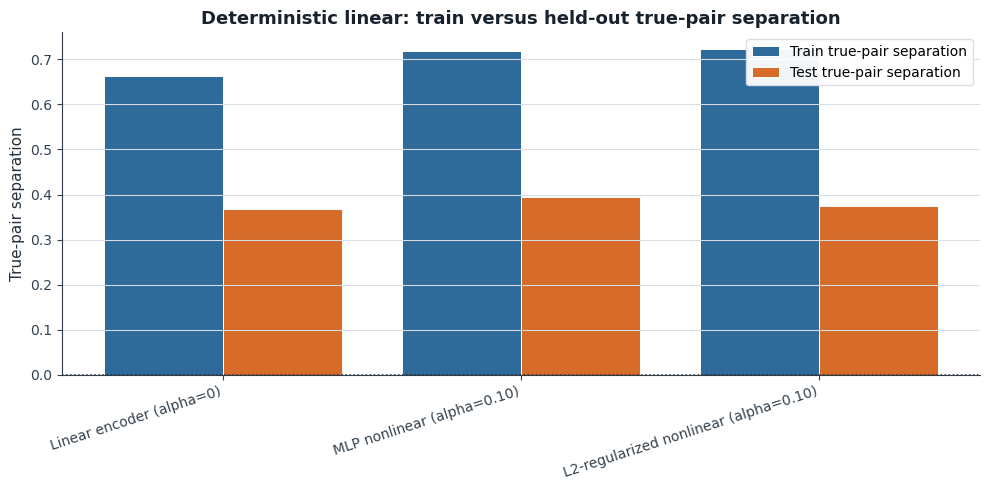

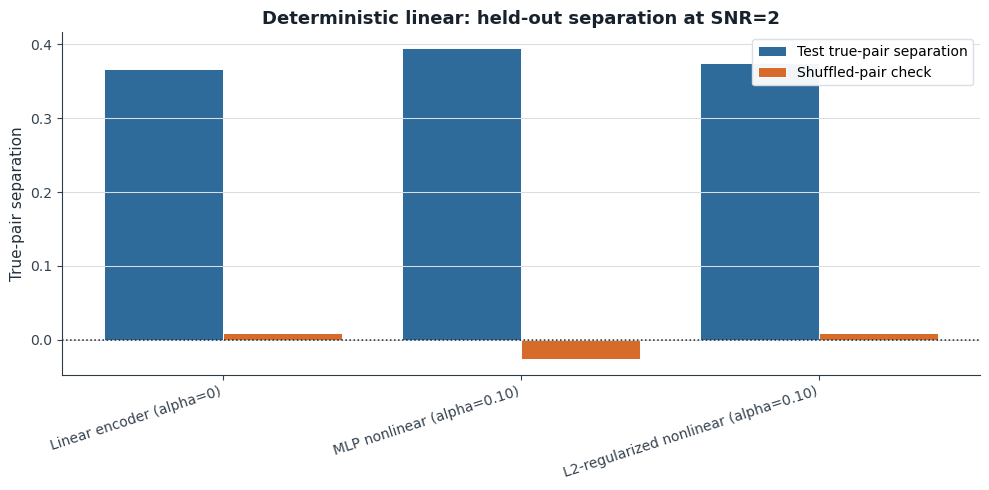

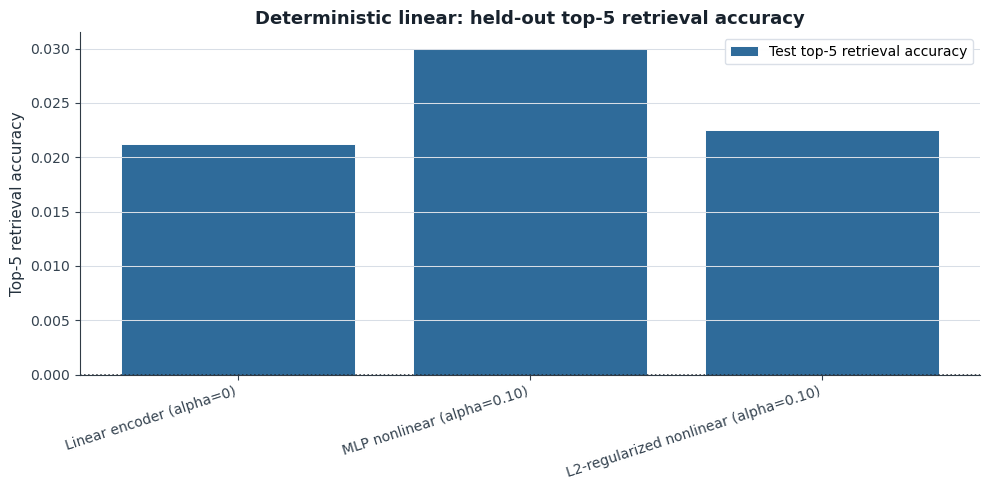

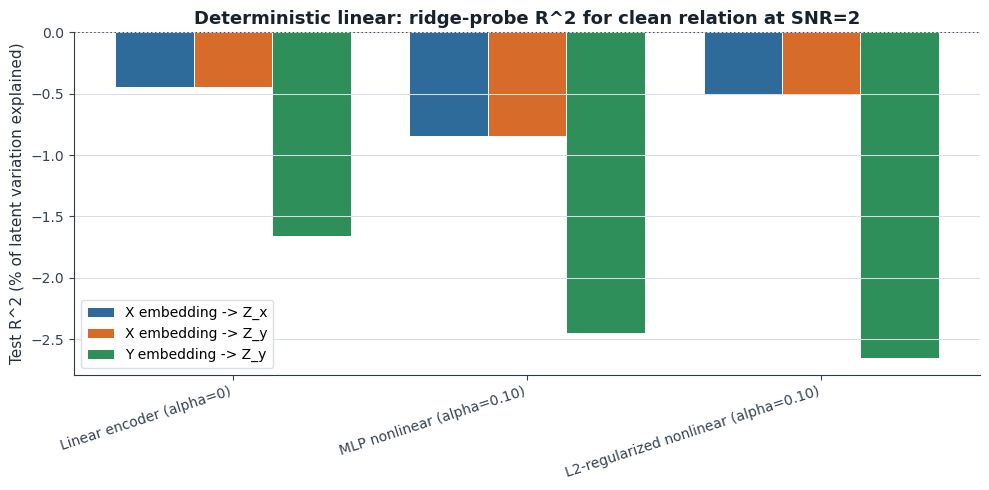

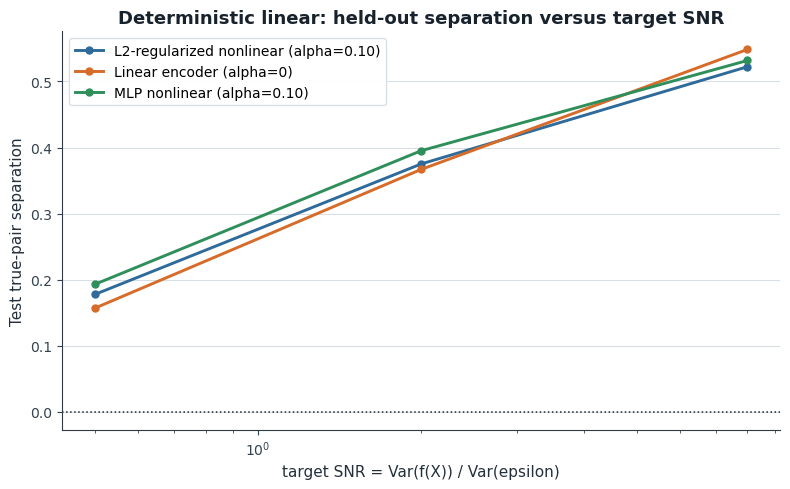

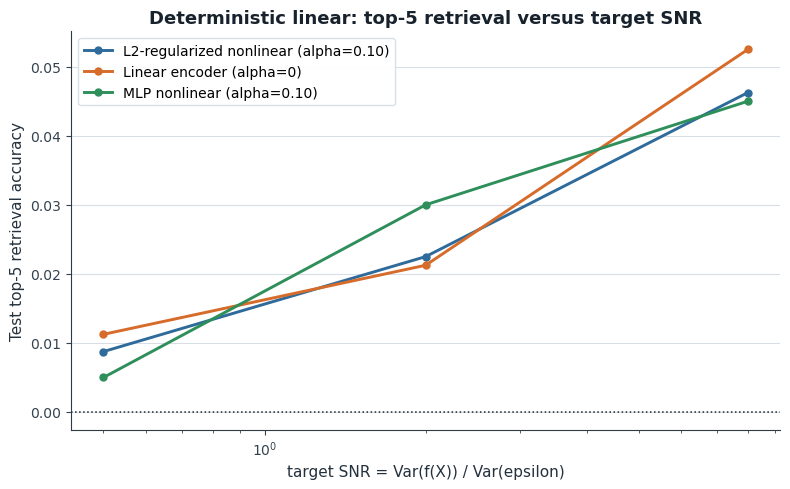

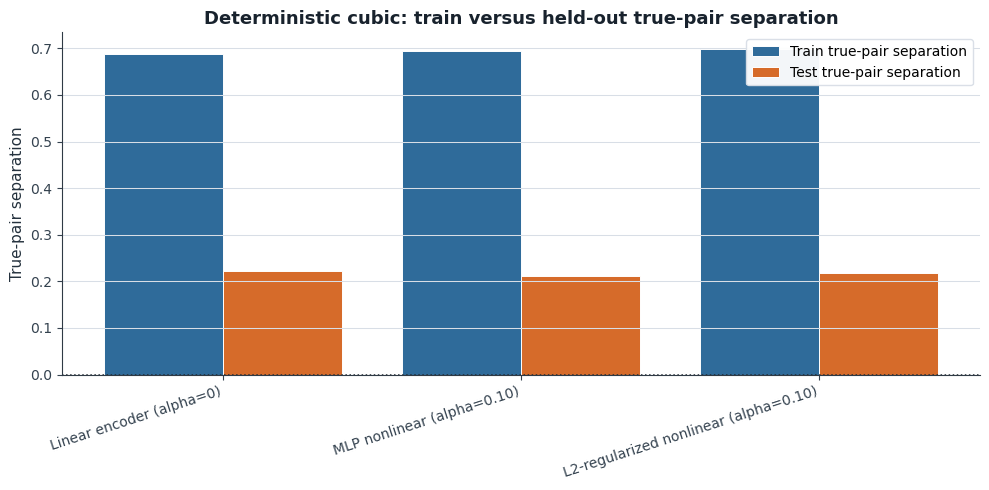

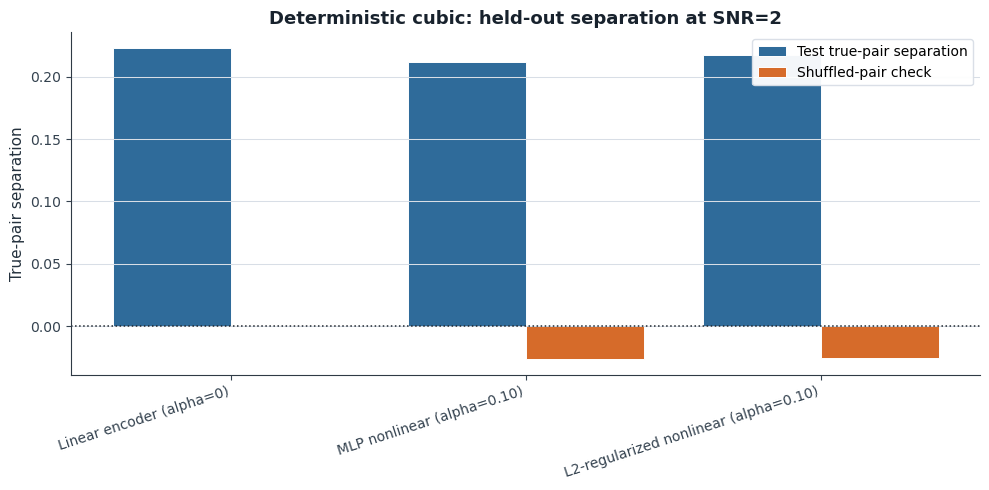

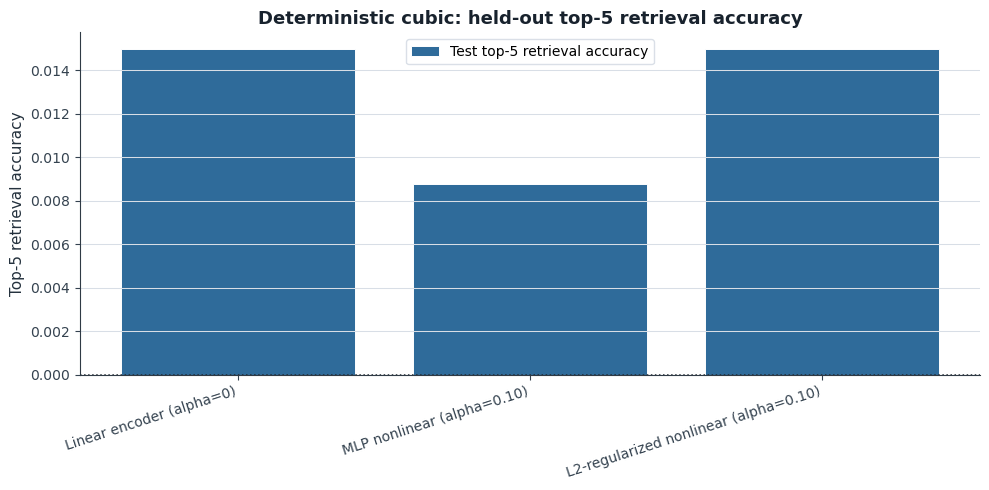

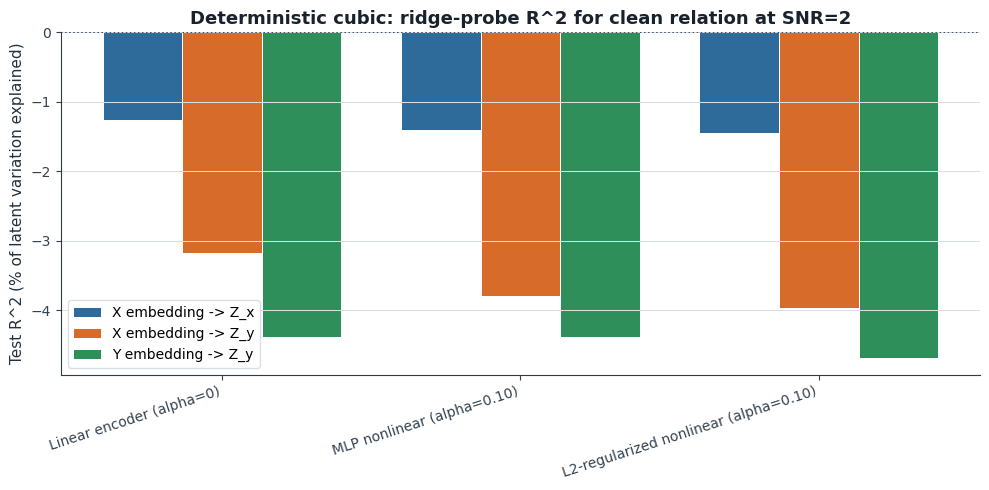

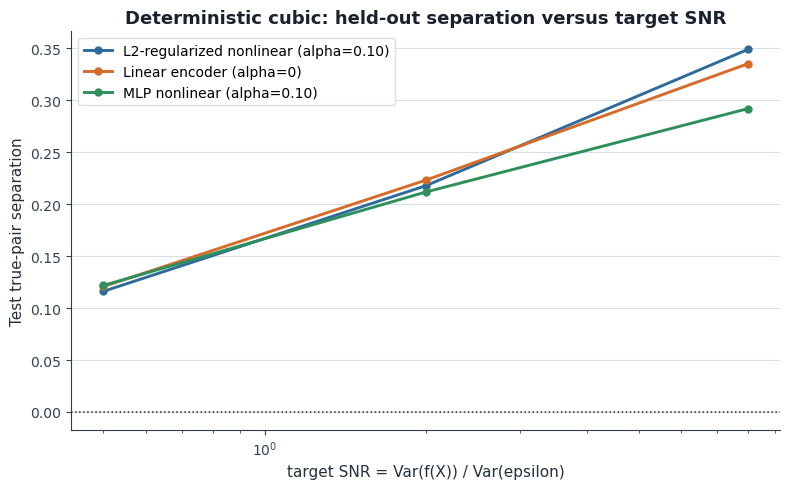

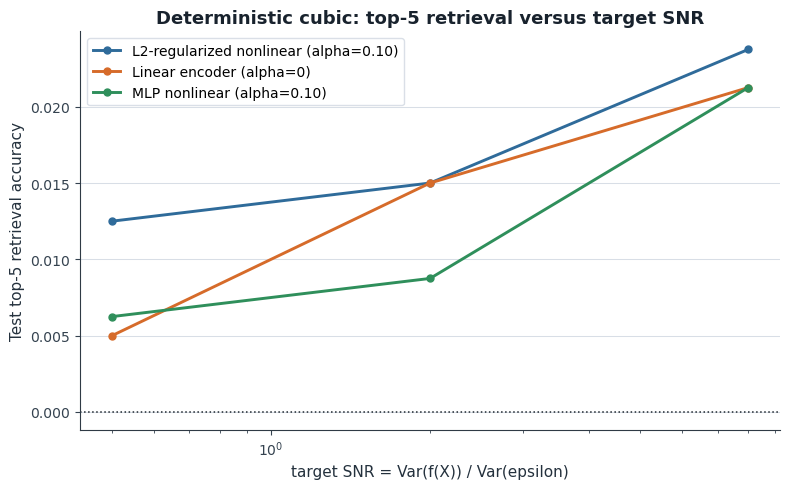

In [11]:
deterministic_snr_2 = deterministic_results[
    deterministic_results["target_snr"] == 2.0
].copy()

for relationship in ["linear", "cubic"]:
    setting_name = f"Deterministic {relationship}"

    plot_train_test_separation_by_setting(
        deterministic_snr_2,
        setting=setting_name,
        save_dir=PLOT_DIR,
    )

    plot_metric_by_config(
        deterministic_snr_2,
        setting=setting_name,
        metrics=["test_pair_separation", "shuffled_pair_separation"],
        title=f"{setting_name}: held-out separation at SNR=2",
        ylabel="True-pair separation",
        save_dir=PLOT_DIR,
    )

    plot_top5_retrieval_by_setting(
        deterministic_snr_2,
        setting=setting_name,
        save_dir=PLOT_DIR,
    )

    plot_latent_probe_r2_by_config(
        deterministic_snr_2,
        setting=setting_name,
        title=f"{setting_name}: ridge-probe R^2 for clean relation at SNR=2",
        save_dir=PLOT_DIR,
    )

    plot_deterministic_snr_sweep(
        deterministic_results,
        relationship=relationship,
        metric="test_pair_separation",
        title=f"{setting_name}: held-out separation versus target SNR",
        save_dir=PLOT_DIR,
    )

    plot_deterministic_snr_sweep(
        deterministic_results,
        relationship=relationship,
        metric="test_top5_pair_match_accuracy",
        title=f"{setting_name}: top-5 retrieval versus target SNR",
        save_dir=PLOT_DIR,
    )
